# MPS → Quantum Circuit (Unitary Gate Decomposition)

Loads a trained MPS and constructs the sequence of unitary quantum gates that
implements the same state-preparation circuit.

## Method (Ran 2020 / isometric extension)

Each MPS tensor `A⁽ʲ⁾ ∈ ℝ^{D_{j-1} × d × D_j}` is reshaped into an isometry:

```
M⁽ʲ⁾ = reshape(A⁽ʲ⁾, D_{j-1}·d, D_j)     [left-canonical ⟹ M†M = I_{D_j}]
```

Because `M⁽ʲ⁾` has more rows than columns (`D_{j-1}·d ≥ D_j` for a
left-canonical MPS), the full SVD `M = U·Σ·Vᵀ` gives a square unitary
`U ∈ ℝ^{(D_{j-1}·d) × (D_{j-1}·d)}` whose first `D_j` columns reproduce
`M` and whose remaining columns span the orthogonal complement:

```
W⁽ʲ⁾ = U    (the unitary gate for site j)
```

The resulting circuit prepares the MPS state from `|0…0⟩` using one
`(D_{j-1}·d) × (D_{j-1}·d)` unitary per site.

---
**Optional Section 5** converts the MPS to `ITensorMPS.MPS` format for use
with the ITensors ecosystem.  It requires `ITensors.jl` and `ITensorMPS.jl`,
which are installed on demand.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using LinearAlgebra, Printf

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


## 1. Configuration

In [2]:
mps_file = "mps_heston.jld2"   # path to a bundle saved by save_mps_bundle

"mps_heston.jld2"

## 2. Load and Left-Canonicalize the MPS

The gate construction requires the MPS to be **left-canonical**: each site
tensor must satisfy `M⁽ʲ⁾† M⁽ʲ⁾ = I`.  `left_canonicalize_mps!` enforces
this via sequential QR sweeps.

In [3]:
mps, nll_hist, epoch_saved, meta = load_mps_bundle(mps_file)

M     = length(mps)
D_max = meta["D_max"]
@printf("Loaded MPS: M=%d  D_max=%d  epoch=%d  NLL=%.4f\n",
        M, D_max, epoch_saved, nll_hist[end])
println("Shapes before canonicalization:")
for j in 1:M
    @printf("  A[%2d]: %s\n", j, size(mps[j]))
end

# Ensure left-canonical form so that reshape(A, Dl*d, Dr)† * reshape(A, Dl*d, Dr) ≈ I
left_canonicalize_mps!(mps)
println("\nLeft-canonicalization done.")

Loaded MPS: M=30  D_max=150  epoch=50  NLL=16.2194
Shapes before canonicalization:
  A[ 1]: (1, 16, 16)
  A[ 2]: (16, 16, 150)
  A[ 3]: (150, 16, 150)
  A[ 4]: (150, 16, 150)
  A[ 5]: (150, 16, 150)
  A[ 6]: (150, 16, 150)
  A[ 7]: (150, 16, 150)
  A[ 8]: (150, 16, 150)
  A[ 9]: (150, 16, 150)
  A[10]: (150, 16, 150)
  A[11]: (150, 16, 150)
  A[12]: (150, 16, 150)
  A[13]: (150, 16, 150)
  A[14]: (150, 16, 150)
  A[15]: (150, 16, 150)
  A[16]: (150, 16, 150)
  A[17]: (150, 16, 150)
  A[18]: (150, 16, 150)
  A[19]: (150, 16, 150)
  A[20]: (150, 16, 150)
  A[21]: (150, 16, 150)
  A[22]: (150, 16, 150)
  A[23]: (150, 16, 150)
  A[24]: (150, 16, 150)
  A[25]: (150, 16, 150)
  A[26]: (150, 16, 150)
  A[27]: (150, 16, 150)
  A[28]: (150, 16, 150)
  A[29]: (150, 16, 16)
  A[30]: (16, 16, 1)

Left-canonicalization done.


## 3. Verify Left-Isometry of Each Site

For a left-canonical site `M[α·σ, β] = reshape(A, Dl·d, Dr)` we should have
`M†M ≈ I_{Dr}`.  Check the residual `‖M†M − I‖_F` for every site.

In [4]:
println("Left-isometry check  (should be ≈ 0, last site may differ)")
println("─"^52)
@printf("%-6s  %-20s  %s\n", "site", "shape", "‖M†M − I‖_F")
println("─"^52)
for j in 1:M
    Dl, d, Dr = size(mps[j])
    Mj  = reshape(mps[j], Dl * d, Dr)
    err = norm(Mj' * Mj - I(Dr))
    flag = err > 1e-4 ? "  ← last site (norm carrier)" : ""
    @printf("  %-4d  (%3d, %2d, %3d)          %.3e%s\n", j, Dl, d, Dr, err, flag)
end

Left-isometry check  (should be ≈ 0, last site may differ)
────────────────────────────────────────────────────
site    shape                 ‖M†M − I‖_F
────────────────────────────────────────────────────
  1     (  1, 16,  16)          3.260e-07
  2     ( 16, 16, 150)          3.136e-06
  3     (150, 16, 150)          5.266e-06
  4     (150, 16, 150)          4.629e-06
  5     (150, 16, 150)          4.735e-06
  6     (150, 16, 150)          4.887e-06
  7     (150, 16, 150)          4.678e-06
  8     (150, 16, 150)          4.135e-06
  9     (150, 16, 150)          4.546e-06
  10    (150, 16, 150)          4.399e-06
  11    (150, 16, 150)          5.151e-06
  12    (150, 16, 150)          4.638e-06
  13    (150, 16, 150)          5.024e-06
  14    (150, 16, 150)          5.570e-06
  15    (150, 16, 150)          4.639e-06
  16    (150, 16, 150)          5.174e-06
  17    (150, 16, 150)          5.434e-06
  18    (150, 16, 150)          5.993e-06
  19    (150, 16, 150)          5.075

## 4. Build Unitary Gates W⁽ʲ⁾

For each site, extend the isometry `M⁽ʲ⁾` to a full square unitary via the
full SVD.  Then verify `W†W ≈ I`.

In [5]:
"""
    mps_to_unitary(Aj) -> W

Given an MPS tensor `Aj` of shape `(Dl, d, Dr)`, return the unitary gate
`W ∈ ℝ^{(Dl·d) × (Dl·d)}` obtained by isometric extension via full SVD.

The first `Dr` columns of `W` reproduce the left-canonical isometry
`reshape(Aj, Dl·d, Dr)`; the remaining columns form the orthogonal complement.
"""
function mps_to_unitary(Aj::AbstractArray{T,3}) where T
    Dl, d, Dr = size(Aj)
    Mj = reshape(Aj, Dl * d, Dr)          # isometry: (Dl·d) × Dr
    F  = svd(Matrix{Float64}(Mj); full = true)   # full SVD → U is (Dl·d) × (Dl·d)
    return T.(F.U)
end

# Build all gates
gates = [mps_to_unitary(mps[j]) for j in 1:M]

println("Unitary gate summary")
println("─"^60)
@printf("%-6s  %-20s  %-20s  %s\n",
        "site", "A shape (Dl,d,Dr)", "W shape", "‖W†W − I‖_F")
println("─"^60)
for j in 1:M
    Dl, d, Dr = size(mps[j])
    W   = gates[j]
    err = norm(W' * W - I(size(W, 1)))
    @printf("  %-4d  (%3d, %2d, %3d)          %-20s  %.3e\n",
            j, Dl, d, Dr, "$(size(W,1))×$(size(W,2))", err)
end

Unitary gate summary
────────────────────────────────────────────────────────────
site    A shape (Dl,d,Dr)     W shape               ‖W†W − I‖_F
────────────────────────────────────────────────────────────
  1     (  1, 16,  16)          16×16                 2.065e-07
  2     ( 16, 16, 150)          256×256               4.090e-06
  3     (150, 16, 150)          2400×2400             1.855e-05
  4     (150, 16, 150)          2400×2400             1.746e-05
  5     (150, 16, 150)          2400×2400             2.055e-05
  6     (150, 16, 150)          2400×2400             3.815e-05
  7     (150, 16, 150)          2400×2400             4.198e-05
  8     (150, 16, 150)          2400×2400             3.553e-05
  9     (150, 16, 150)          2400×2400             3.169e-05
  10    (150, 16, 150)          2400×2400             3.125e-05
  11    (150, 16, 150)          2400×2400             3.272e-05
  12    (150, 16, 150)          2400×2400             2.961e-05
  13    (150, 16, 150)   

## 5. Schmidt Spectra and Entanglement Entropy

The singular values of individual **site tensors** are all identically 1 for a
left-canonical MPS (that is the definition of left-isometry), so they carry no
entanglement information.

The physically meaningful quantity is the **Schmidt spectrum at each bond**:
the singular values of the bipartite split `[sites 1..b | sites b+1..M]`.
`bipartite_entropies` computes this via a right-to-left SVD sweep without
mutating the MPS.

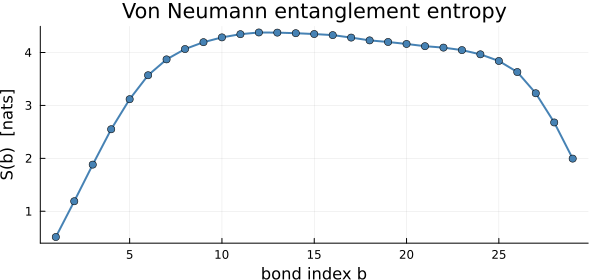

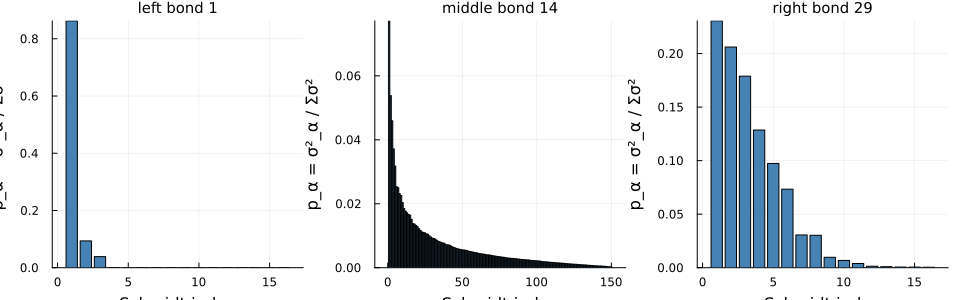

In [6]:
using Plots

# Schmidt spectra at every bond (right-to-left SVD sweep; does not mutate mps)
Svals, entr = bipartite_entropies(mps)
n_bonds = length(Svals)   # = M - 1

# ── Panel 1: entanglement entropy profile across all bonds ───────────────────
p_entr = plot(1:n_bonds, entr;
    lw=2, marker=:circle, markersize=4, color=:steelblue,
    xlabel = "bond index b",
    ylabel = "S(b)  [nats]",
    title  = "Von Neumann entanglement entropy",
    legend = false, size = (600, 280))
display(p_entr)

# ── Panel 2: Schmidt spectra at left, middle, and right bonds ────────────────
showcase_bonds = unique([1, max(1, n_bonds ÷ 2), n_bonds])
labels = Dict(1 => "left bond 1",
              n_bonds => "right bond $n_bonds",
              max(1, n_bonds ÷ 2) => "middle bond $(max(1, n_bonds ÷ 2))")

spec_plots = []
for b in showcase_bonds
    sv  = Svals[b]
    p2  = sv .^ 2
    p2 ./= sum(p2)   # normalise to prob weights for cleaner y-axis
    push!(spec_plots, bar(p2;
        title  = labels[b],
        xlabel = "Schmidt index",
        ylabel = "p_α = σ²_α / Σσ²",
        color  = :steelblue,
        legend = false,
        titlefontsize = 10))
end

plot(spec_plots...; layout = (1, length(spec_plots)),
     size = (320 * length(spec_plots), 300))

## 6. (Optional) Convert to ITensorMPS Format

The cell below installs `ITensors.jl` and `ITensorMPS.jl` on demand and
converts the array-MPS to the ITensorMPS native format.  This lets you use
the full ITensors ecosystem (DMRG, time evolution, etc.) on the trained model.

> **Note:** ITensors.jl is a large package (~1 min first install).  The rest
> of this notebook runs without it.

In [7]:
# Install ITensors/ITensorMPS if not already present.
# Remove the `return` below to enable this section.
return

Pkg.add(["ITensors", "ITensorMPS"])
using ITensors, ITensorMPS

   Resolving package versions...
   Installed SplitApplyCombine ────── v1.3.0
   Installed ArrayInterface ───────── v7.25.0
   Installed Static ───────────────── v1.4.0
   Installed StaticArrayInterface ─── v1.10.0
   Installed Zeros ────────────────── v0.5.0
   Installed SimpleTraits ─────────── v0.9.6
   Installed Strided ──────────────── v2.6.0
   Installed KrylovKit ────────────── v0.10.3
   Installed NDTensors ────────────── v0.4.28
   Installed ITensorMPS ───────────── v0.4.1
   Installed TypeParameterAccessors ─ v0.4.23
   Installed ITensors ─────────────── v0.9.30
      Compat entries added for ITensors, ITensorMPS
    Updating `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
  [0d1a4710] + ITensorMPS v0.4.1
  [9136182c] + ITensors v0.9.30
    Updating `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`
  [7d9f7c33] + Accessors v0.1.44
  [dce04be8] + ArgCheck v2.5.0
  [4fba245c] + ArrayInterface v7.

In [8]:
# Remove the `return` in the cell above to reach this cell.

"""
    arrays_to_itensormps(mps_arr, d) -> (ψ::MPS, sites)

Convert a Vector{Array{T,3}} (MPSFast format) to an ITensorMPS.MPS.
All sites are assumed to have the same physical dimension `d`.
"""
function arrays_to_itensormps(mps_arr, d)
    Ml    = length(mps_arr)
    sites = [Index(d; tags = "Site,n=$j") for j in 1:Ml]
    bonds = [size(mps_arr[j], 3) for j in 1:Ml-1]
    lnks  = [Index(bonds[j]; tags = "Link,l=$j") for j in 1:Ml-1]
    T_arr = Vector{ITensor}(undef, Ml)
    T_arr[1]  = ITensor(mps_arr[1][1,  :, :], sites[1], lnks[1])
    for j in 2:Ml-1
        T_arr[j] = ITensor(mps_arr[j],         lnks[j-1], sites[j], lnks[j])
    end
    T_arr[Ml] = ITensor(mps_arr[Ml][:, :, 1], lnks[Ml-1], sites[Ml])
    return MPS(T_arr), sites
end

d_phys  = size(mps[1], 2)
ψ, sites_it = arrays_to_itensormps(mps, d_phys)

println("ITensorMPS conversion:")
println("  type  = ", typeof(ψ))
println("  bonds = ", ITensorMPS.linkdims(ψ))

# Cross-validate norm squared: ITensorMPS ⟨ψ|ψ⟩ vs MPSFast Z
Z_itensor = Float64(real(ITensorMPS.inner(ψ, ψ)))
Z_arrays  = Float64(exp(log_partition_function(mps)))
@printf("\nNorm² cross-check:\n")
@printf("  ITensorMPS ⟨ψ|ψ⟩ = %.8f\n", Z_itensor)
@printf("  MPSFast    Z      = %.8f\n", Z_arrays)
@printf("  relative error    = %.2e\n", abs(Z_itensor - Z_arrays) / max(Z_arrays, 1e-30))

ITensorMPS conversion:
  type  = MPS
  bonds = [16, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 150, 16]

Norm² cross-check:
  ITensorMPS ⟨ψ|ψ⟩ = 0.99999213
  MPSFast    Z      = 0.99999213
  relative error    = 0.00e+00
